# 03 · Price elasticity by region — random slopes & endogeneity

**The business decision.** We set prices region by region and want each region's **price elasticity of
demand** — the standard economics measure of how sensitive demand is to price. Concretely, elasticity is
the **% change in quantity sold for a 1% change in price**; it's almost always negative (raise price →
sell less). An elasticity of −1.5 means "cut price 1%, sell 1.5% more." We need it per region because a
tourist market and a price-sensitive suburb should not be priced the same.

### Two traps this notebook is built around

1. **Small regions are noisy.** A region with 12 weeks of data will hand you a wild elasticity estimate
   that's mostly sampling noise. Acting on it is overfitting. The fix is **partial pooling** (below).
2. **Price is endogenous.** "Endogenous" means the treatment (price) is *correlated with the error term*
   — here because managers historically *cut prices when they expected soft demand*. So low prices
   coincide with low demand for reasons that have nothing to do with the price cut, which drags the naive
   elasticity estimate *toward zero* (makes demand look less price-sensitive than it is). No amount of
   clever averaging fixes this — it needs an **instrument** (notebook 11), which we preview at the end.

### The tools, in plain terms

- **Log-log demand.** We model $\log(\text{quantity}) = \alpha + \beta\,\log(\text{price}) + \dots$. The
  magic of taking logs on both sides is that the slope $\beta$ **is** the elasticity directly (a constant
  %-for-% relationship), so there's one interpretable number per region. One line of calculus shows why:
  elasticity is defined as $\epsilon(P) \equiv \frac{dQ}{dP}\cdot\frac{P}{Q}$, and for the
  constant-elasticity curve $Q = A P^{\beta}$ we get
  $\epsilon(P) = \beta A P^{\beta-1}\cdot\frac{P}{A P^{\beta}} = \beta$ — the *same* $\beta$ at
  every price point. For **any other** demand shape the elasticity moves with the price level, so $\beta$
  is best read as a *local approximation around the prices we actually observed* — a point that returns
  with teeth when we recommend prices outside that range.
- **Random slopes / partial pooling.** Instead of one elasticity for all regions (ignores real
  differences) or a separate free estimate per region (noisy), we assume each region's elasticity
  $\beta_r$ is drawn from a shared distribution $\beta_r \sim \mathcal{N}(\mu_\beta, \tau_\beta^2)$. This
  **hierarchical** structure makes each region's estimate a compromise between its own noisy data and the
  fleet average — data-poor regions get pulled ("shrunk") harder toward the fleet, which is exactly the
  protection we want. $\mu_\beta$ is the typical elasticity; $\tau_\beta$ measures how much regions
  genuinely differ.

> Cookbook maps this to `pathmc` random slopes; here we fit the equivalent hierarchical model explicitly
> in PyMC so the shrinkage is fully visible. The identification logic is unchanged.

> **On real data.** Swap in your **own transaction panel** — one row per region per week with price,
> units sold, and controls (competitor price, promotions, seasonality). Public analogues are retail
> *scanner* datasets (e.g. the Dominick's Finer Foods store data). The endogeneity caveat is not academic:
> it's the single biggest reason naive "price tests" mislead in practice.


In [1]:
import os, json, warnings, logging, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pymc as pm
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)  # SamplerWarnings log at ERROR; silence fully
from scipy import stats
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=500, tune=500, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 5

## 2 · Simulate a ground truth

A region × week panel with a **constant-elasticity (log-log) demand curve**
$\log Q_{rt}=\alpha_r+\beta_r\log P_{rt}+\gamma^\top Z_{rt}+\varepsilon_{rt}$, where $\beta_r$ is
region $r$'s true price elasticity (planted, varying around a fleet mean ≈ −1.4). Of the observed covariates $Z$, only **competitor price** is a genuine confounder — it moves both
our price and demand; **season** and **trend** shift demand only, so they enter as *precision
covariates* (they sharpen estimates), not confounders. We start with **no** endogeneity so we
can show recovery, then switch it on in step 8.

**The data-generating model** — exactly what `dgp.price_panel` implements (defaults & seed in
`src/cmp/dgp.py`). For region $r$, week $t$: season $s_t = 0.3\sin(2\pi t/26)$, trend
$g_t = 0.01\,t$, competitor price $C_{rt} \sim \mathcal N(20,\, 2^{2})$, and a demand shock
$u_{rt} \sim \mathcal N(0,1)$:

$$
\begin{aligned}
\beta_r &\sim \mathcal N(-1.4,\; 0.35^{2})\\[2pt]
\log P_{rt} &= \log 15 \;-\; 0.05\, C_{rt}/20 \;+\; \kappa\, u_{rt} \;+\; \nu_{rt},
  \qquad \nu_{rt} \sim \mathcal N(0,\, 0.05^{2})\\[2pt]
\log Q_{rt} &= 2.5 \;+\; \beta_r \log P_{rt} \;+\; 0.4\,\tfrac{C_{rt}-20}{20} \;+\; s_t \;+\; g_t
  \;+\; u_{rt} \;+\; \varepsilon_{rt}, \qquad \varepsilon_{rt} \sim \mathcal N(0,\, 0.08^{2}).
\end{aligned}
$$

Line 1 plants the true regional elasticities; line 2 is the price-setting rule; line 3 is
demand. $C_{rt}$ appears in **both** equations — that is what makes competitor price the genuine confounder
(it moves our price *and* demand), while $s_t$ and $g_t$ appear only in the demand equation
(precision covariates). $\kappa$ is the **endogeneity switch**: through step 6 the generator runs with $\kappa = 0$
and zeroes the shock entirely ($u_{rt} \equiv 0$), so recovery is clean; step 8 sets
$\kappa > 0$, and the *same* shock now enters both equations — managers' prices respond to the
very shock that moves demand ($\text{Cov}(\log P, u) > 0$), the simultaneity that biases the
naive elasticity toward zero.


In [2]:
df, true_elast = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=0.0, seed=SEED)
df["log_price"] = np.log(df["price"]); df["log_demand"] = np.log(df["demand"])
regions = sorted(df["region"].unique()); R = len(regions)
r_idx = df["region"].map({r: i for i, r in enumerate(regions)}).values
# deliberately thin out a few regions so shrinkage has something to do
keep = np.ones(len(df), bool)
for i in [0, 1, 2]:
    ridx = np.where(r_idx == i)[0]
    drop = np.random.default_rng(i).choice(ridx, size=int(len(ridx) * 0.8), replace=False)
    keep[drop] = False
df, r_idx = df[keep].reset_index(drop=True), r_idx[keep]
counts = pd.Series(r_idx).value_counts().sort_index()
print(f"{R} regions, fleet-mean elasticity {true_elast.mean():.2f}; obs per region range {counts.min()}–{counts.max()} "
      f"(regions 0-2 are thin, to exercise shrinkage)")
df.head()

12 regions, fleet-mean elasticity -1.42; obs per region range 16–80 (regions 0-2 are thin, to exercise shrinkage)


,region,week,price,demand,competitor_price,season,trend,log_price,log_demand
0,region_00,2,13.003239,0.159630,20.405765,1.394170e-01,0.02,2.565199,-1.834900
1,region_00,3,14.245949,0.157405,16.535730,1.989368e-01,0.03,2.656473,-1.848934
2,region_00,12,14.310937,0.159097,20.819276,7.179470e-02,0.12,2.661024,-1.838239
3,region_00,13,15.626376,0.175255,21.659711,-9.648736e-17,0.13,2.748960,-1.741513
4,region_00,15,13.204126,0.152195,19.486540,-1.394170e-01,0.15,2.580529,-1.882592


## 3 · Identify — what must be true for $\beta_r$ to be causal?

**Identification vs estimation.** *Identification* asks whether the causal quantity could be recovered
from this data even with infinite samples — a question about **assumptions**, settled before any fitting;
*estimation* is the statistics we do once identification is granted. Partial pooling (below) is an
**estimation** device — it buys variance reduction, never identification.

**Estimand.** Region $r$'s elasticity is a *causal* slope — what happens to demand when **we** move the
price, not when the market moves it for us:

$$
\beta_r \;=\; \frac{\partial\, \mathbb{E}\big[\log Q \,\big|\, \mathrm{do}(\log P = p),\, r\big]}{\partial p},
$$

where $\mathrm{do}(\cdot)$ marks an *intervention* on price (Pearl's do-operator), as opposed to passively
observing whatever prices managers happened to choose. The regression slope equals this causal slope only
under assumptions — four of them, each named, formalized, and honestly labelled as checkable or not:

**A1 · Conditional price exogeneity** (the continuous-treatment version of **unconfoundedness** — once we hold the observed controls fixed, price is as-good-as-randomly assigned with respect to the demand shock):

$$
\varepsilon_{rt} \;\perp\; \log P_{rt} \;\big|\; Z_{rt},\, r .
$$

After conditioning on region and the observed controls $Z$, whatever noise remains in demand must be
unrelated to how the price was set. The one true observable confounder in our DGP is **competitor price**
— it moves both $P$ and $Q$, opening a **backdoor path** in the DAG below — a *backdoor path* is a non-causal route linking price and demand through a common cause (here $P \leftarrow$ competitor price $\rightarrow Q$) that manufactures correlation which is *not* the price effect — and conditioning on it closes
that path. **Season** and **trend** move demand only, so they are *precision covariates* (they sharpen
estimates), not confounders. A1 holds by construction while $\kappa=0$; it is *exactly* the assumption we
break in step 8, and it is **untestable from the data alone** — no diagnostic in this notebook can
certify it.

**A2 · Price variation — genuine price movement left after the controls** (the continuous-treatment form of **positivity**):

$$
\mathrm{Var}(\log P_{rt} \mid Z_{rt},\, r) \;>\; 0 .
$$

Each region must have genuine price movement left over after the controls; no variation, no slope. In the
DGP this is the quasi-experimental wiggle $\nu_{rt}\sim\mathcal N(0,\,0.05^2)$ — checked numerically in
the next cell. In real data this is the assumption most often *silently* violated: uniform corporate
pricing or rigid cost-plus rules leave $\mathrm{Var}(\log P \mid Z)\approx 0$, and the "elasticity" you
then estimate is noise dressed up as a number.

**A3 · No dynamic effects / SUTVA** (Stable Unit Treatment Value Assumption)**.** This week's price affects this week's demand only: no stockpiling
("pantry-loading" ahead of a price rise), no delayed reference-price effects, and no cross-region
spillovers (region A's price doesn't move region B's demand — no arbitrage). Our DGP satisfies this by
construction; on real scanner data a `lag(price)` term is the standard first probe (step 8's caveats).

**A4 · Functional form.** In a *parametric* model the constant-elasticity (log-log) shape is part of the
identification bundle: if the true curve bends, the "constant" $\beta_r$ is a price-range-specific
average. We stress-test this in-sample in step 5 with a curvature term — but no in-sample check reaches
prices we never charged.

**Partial pooling, and what it buys.** The estimand is per-region, so we treat elasticity as a **random
slope**: $\beta_r\sim\mathcal N(\mu_\beta,\tau_\beta^2)$ — noisy regions shrink toward the fleet
mean $\mu_\beta$, and $\tau_\beta$ (a standard deviation — the between-region spread of elasticities) *measures how much elasticity genuinely varies*. The
**shrinkage factor** for region $r$ is approximately
$\;1-\dfrac{\tau_\beta^2}{\tau_\beta^2+\sigma^2/n_r}\;$ — thin regions (small $n_r$) get pulled
harder toward the fleet. Shrinkage is a feature: it stops us over-reacting to a small region's
noisy slope. But pooling handles *noise*, not *bias*: if A1 fails, all three pooling regimes in step 4
are biased by the same amount.

**How big is the bias if A1 fails? Two lines of algebra, not hand-waving.** Suppose an unobserved shock
$u_{rt}$ (variance $\sigma_u^2$) enters demand with coefficient 1 *and* leaks into price with coefficient
$\kappa$ (managers cut price when they expect soft demand). For the regression of $\log Q$ on $\log P$
after partialling out $Z$ and region effects (i.e. after regressing price and demand on the controls and keeping only the residual variation), the classic **omitted-variable-bias** formula gives

$$
\hat\beta \;\xrightarrow{\;p\;}\; \beta \;+\; \frac{\mathrm{Cov}(\log P,\, u)}{\mathrm{Var}(\log P)}
\;=\; \beta \;+\; \frac{\kappa\,\sigma_u^2}{\kappa^2\sigma_u^2 + \sigma_\nu^2},
$$

using the DGP's price equation ($\mathrm{Cov}(\log P, u)=\kappa\sigma_u^2$ and
$\mathrm{Var}(\log P \mid Z)=\kappa^2\sigma_u^2+\sigma_\nu^2$). The arrow $\xrightarrow{p}$ reads "converges in probability to" — the value the estimate settles on as the sample grows. The bias term is **positive**, and since
$\beta<0$ it drags $\hat\beta$ **toward zero** — demand looks less price-sensitive than it is. Worse, the
*sign of the whole slope can flip*: when the exogenous wiggle $\sigma_\nu$ is small, even a faint
$\kappa$ makes the bias enormous (the denominator is tiny) and the fitted "demand curve" slopes *upward*
— high prices coinciding with high demand because both chase the same shock. Step 8 verifies this
arithmetic numerically, then sweeps $\kappa$ to map the whole curve. What pooling does **not** fix is
exactly this: an *unobserved* common shock needs an instrument — previewed in step 8, full treatment in
notebook 11. We state this out loud rather than hide it.

A2 check — within-region SD of log-price: min 0.046, median 0.052, max 0.058 (all comfortably > 0: positivity holds, by design)


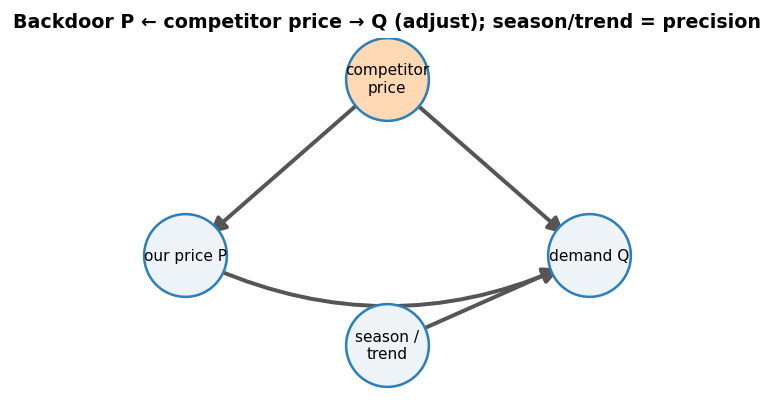

In [3]:
# The DAG behind the estimand. Competitor price is the confounder — it moves BOTH our price
# and demand, opening the backdoor P <- competitor -> Q we must adjust for. Season/trend push
# demand only (precision covariates). The causal arrow of interest is P -> Q (elasticity beta).
fig, axd = plt.subplots(figsize=(5.6, 3.2))
plots.draw_dag(
    axd,
    pos={"competitor\nprice": (0.5, 1.0), "our price P": (0.12, 0.35),
         "demand Q": (0.88, 0.35), "season /\ntrend": (0.5, 0.02)},
    edges=[("competitor\nprice", "our price P"), ("competitor\nprice", "demand Q"),
           ("our price P", "demand Q"), ("season /\ntrend", "demand Q")],
    node_colors={"competitor\nprice": "#ffd9b3"},
    curved={("our price P", "demand Q")},
    title="Backdoor P \u2190 competitor price \u2192 Q (adjust); season/trend = precision")
fig.tight_layout()

# A2 positivity check: genuine within-region price variation (the DGP plants nu ~ N(0, 0.05^2) of
# quasi-experimental wiggle on top of the competitor-price passthrough). Were these ~0, no elasticity
# could be identified in that region no matter how clever the model.
lp_sd = df.groupby("region")["log_price"].std()
print(f"A2 check — within-region SD of log-price: min {lp_sd.min():.3f}, median {lp_sd.median():.3f}, "
      f"max {lp_sd.max():.3f} (all comfortably > 0: positivity holds, by design)")

## 4 · Estimate — three pooling regimes, side by side

To make the bias–variance trade-off concrete we estimate each region's elasticity **three ways**:

- **No pooling** — a separate regression per region. Unbiased, but a data-poor region's estimate is pure
  noise. This is the "trust each region's own numbers" extreme.
- **Complete pooling** — one elasticity for the whole fleet. Rock-steady, but pretends every region is
  identical, so it's biased for any region that genuinely differs. The "everyone's the same" extreme.
- **Partial pooling** — the hierarchical Bayesian middle ground: each $\beta_r$ is nudged toward the fleet
  mean by an amount that depends on how much data the region has. Data-rich regions barely move; data-poor
  regions borrow heavily. This is the one that gets *both* the overall level and the spread right.

The model below reads directly as the maths from Step 3: `mu_beta` is the fleet-mean elasticity $\mu_\beta$,
`tau_beta` is how much regions differ $\tau_\beta$, and `beta_r` are the per-region elasticities drawn from
$\mathcal{N}(\mu_\beta,\tau_\beta^2)$. `alpha_r` are region baselines and `gamma` the controls (competitor
price, seasonality, trend). The printout compares the recovered fleet mean to the planted truth.

**The fitted model, in symbols** (observation $i$ in region $r[i]$; $z_i$ the standardized
controls — competitor price, season, trend):

$$
\begin{aligned}
\log Q_i &\sim \mathcal N\big(\alpha_{r[i]} + \beta_{r[i]} \log P_i + \gamma^\top z_i,\;
  \sigma^{2}\big)\\[2pt]
\beta_r &\sim \mathcal N(\mu_\beta,\, \tau_\beta^{2}), \qquad
\alpha_r \sim \mathcal N(0,\, 5^{2}), \qquad
\gamma \sim \mathcal N(0,\, 2^{2})\\[2pt]
\mu_\beta &\sim \mathcal N(-1,\, 1^{2}), \qquad
\tau_\beta \sim \text{HalfNormal}(1), \qquad
\sigma \sim \text{HalfNormal}(1).
\end{aligned}
$$

The middle line's $\beta_r \sim \mathcal N(\mu_\beta, \tau_\beta^{2})$ **is** the partial pooling:
$\tau_\beta$ (how much regions truly differ) is *learned from the data*, and each region's posterior
elasticity is a precision-weighted compromise between its own weeks and the fleet mean — thin
regions lean on the fleet, data-rich regions stand on their own.

**Why these priors.** $\mu_\beta \sim \mathcal N(-1, 1)$ puts ~95% of its mass on $(-3, +1)$: it spans
everything from mildly inelastic demand to $\beta\approx-3$ (more price-sensitive than almost any retail
elasticity ever measured) while gently centering on the economically plausible region — and it is weak
enough that the panel dominates it easily. $\tau_\beta \sim \text{HalfNormal}(1)$ lets the data choose the
**pooling regime itself**: $\tau_\beta \to 0$ collapses to complete pooling (all regions identical), large
$\tau_\beta$ approaches no pooling (every region on its own) — the two baselines above are the *limiting
cases* of the model we actually fit, and where we land between them is *learned*, not assumed.
$\alpha_r \sim \mathcal N(0,5)$ is diffuse for log-scale intercepts, $\gamma \sim \mathcal N(0,2)$ is
weakly informative for standardized controls, and $\sigma \sim \text{HalfNormal}(1)$ is generous for
log-demand residual noise (the DGP's is 0.08).

**A practitioner's note on parametrization.** We fit the *centered* form
$\beta_r \sim \mathcal N(\mu_\beta, \tau_\beta^2)$, and here it samples cleanly (check the divergence
count in the convergence report below). But centered hierarchies are *the* canonical NUTS pitfall: with
few groups or weak data the joint posterior of $(\tau_\beta, \beta_r)$ develops a **funnel** — as
$\tau_\beta \to 0$ the $\beta_r$ are squeezed into an ever-narrower band the sampler cannot enter. The
standard fix is the **non-centered** form $\beta_r = \mu_\beta + \tau_\beta\,\tilde\beta_r$ with
$\tilde\beta_r \sim \mathcal N(0,1)$, which decorrelates the geometry. If you port this notebook to a
panel with 4 regions and 12 weeks, switch to non-centered first.

**Like-for-like baselines.** The no-pool and complete-pool baselines are fit with the **same standardized
controls $Z$** (competitor price, season, trend) as the hierarchical model — per-region OLS and pooled OLS
with region intercepts, respectively — so the MAE comparison in step 6 isolates the **pooling choice**
and nothing else. (An earlier draft used bivariate $\log Q$-on-$\log P$ fits for the baselines, which
conflated the pooling choice with the control choice; clean comparisons are four lines of code, so we
make them.)

In [4]:
z = df[["competitor_price", "season", "trend"]].values; z = (z - z.mean(0)) / z.std(0)
lp = df["log_price"].values; ld = df["log_demand"].values

with pm.Model() as model:
    mu_beta = pm.Normal("mu_beta", -1.0, 1.0)
    tau_beta = pm.HalfNormal("tau_beta", 1.0)
    beta_r = pm.Normal("beta_r", mu_beta, tau_beta, shape=R)
    alpha_r = pm.Normal("alpha_r", 0, 5, shape=R)
    gamma = pm.Normal("gamma", 0, 2, shape=z.shape[1])
    sigma = pm.HalfNormal("sigma", 1.0)
    mu = alpha_r[r_idx] + beta_r[r_idx] * lp + z @ gamma
    pm.Normal("obs", mu=mu, sigma=sigma, observed=ld)
    idata = pm.sample(random_seed=SEED, progressbar=False, **FIT)

beta_post = idata.posterior["beta_r"].values.reshape(-1, R)
partial = beta_post.mean(0)
print(f"hierarchical model convergence: {est.convergence_report(idata, var_names=['mu_beta','tau_beta','sigma'])['summary']}")

# Like-for-like baselines (see step-4 text): SAME standardized controls Z as the hierarchical model.
# No pooling = per-region OLS of log Q on [1, log P, Z]; complete pooling = pooled OLS with region
# intercepts (dummies) and ONE shared slope. The three fits now differ ONLY in how the slope is pooled.
def _ols(X, y):
    return np.linalg.lstsq(X, y, rcond=None)[0]

nopool = np.array([_ols(np.column_stack([np.ones(int((r_idx == i).sum())), lp[r_idx == i], z[r_idx == i]]),
                        ld[r_idx == i])[1] for i in range(R)])
complete = float(_ols(np.column_stack([np.eye(R)[r_idx], lp, z]), ld)[R])
print(f"fleet-mean elasticity μ_β {idata.posterior['mu_beta'].values.mean():.2f} (true {true_elast.mean():.2f})  ·  "
      f"between-region spread τ_β {idata.posterior['tau_beta'].values.mean():.2f} (true {true_elast.std():.2f})")

hierarchical model convergence: max r-hat 1.010 - min ESS 251 - divergences 0
fleet-mean elasticity μ_β -1.36 (true -1.42)  ·  between-region spread τ_β 0.31 (true 0.31)


**Reading the convergence line.** Those three numbers are the sampler's health check — whether the MCMC sampler (the algorithm drawing from the posterior) actually converged. **R-hat** compares the variance *within* each chain to the variance *across* chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar** (above it the chains disagree and the numbers aren't safe to read). **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth — a few hundred is ample for a posterior mean or a 90% interval. **Divergences** are steps where the sampler broke down and silently distrusts that region — for this centered hierarchy they are the funnel warning flagged above, and **you want 0**. All three pass here, so the estimates below are safe to read. (Under the FAST teaching profile the chains are short, so R-hat can drift to ~1.02 and PyMC may print a "problems during sampling" notice — a benign artifact of the small draw count that clears in a FULL run.)

## 5 · Check the model *before* grading it — posterior predictive & functional form

Discipline first: before we congratulate the model on recovering the planted truth (a luxury a real
analyst never has), we run the checks a real analyst *can* run.

- **Posterior predictive check (PPC).** Simulate replicated datasets $\log Q^{\mathrm{rep}}$ from the
  fitted model and overlay their distribution on the observed $\log Q$. If the cloud of replicates fails
  to cover the data — wrong location, spread, or shape — the model is structurally wrong somewhere.
- **Residuals against log-price and against week.** Curvature in residuals-vs-$\log P$ is exactly what a
  violated constant-elasticity assumption (A4) looks like; leftover structure in residuals-vs-week means
  missed seasonality or dynamics (A3).
- **A curvature term as a formal probe of A4.** We add $(\log P - \overline{\log P})^2$ to a pooled OLS
  with the same controls and check whether its coefficient is distinguishable from zero.

**And the sentence that matters most:** a clean PPC certifies **fit, not causality**. The endogenous
model of step 8 — wrong by nearly a full elasticity point — would sail through this same PPC, because
confounding is invisible in the distribution of the outcome alone. PPC failures tell you the model is
wrong; PPC successes do **not** tell you it is right about the causal question. That was assumption A1,
and A1 is untestable. Keep the two firmly apart.

A4 curvature probe — coefficient on (log P − mean)²: -0.9 (SE 0.8, t = -1.0) → consistent with zero -> constant elasticity survives in-sample
note the wide SE: with only ±5% price wiggle this test has little power far from current prices —
another reason to treat any P* outside the observed range as extrapolation, not measurement.
PPC replicate mean -0.70 vs observed -0.70; replicate SD 0.88 vs observed 0.88


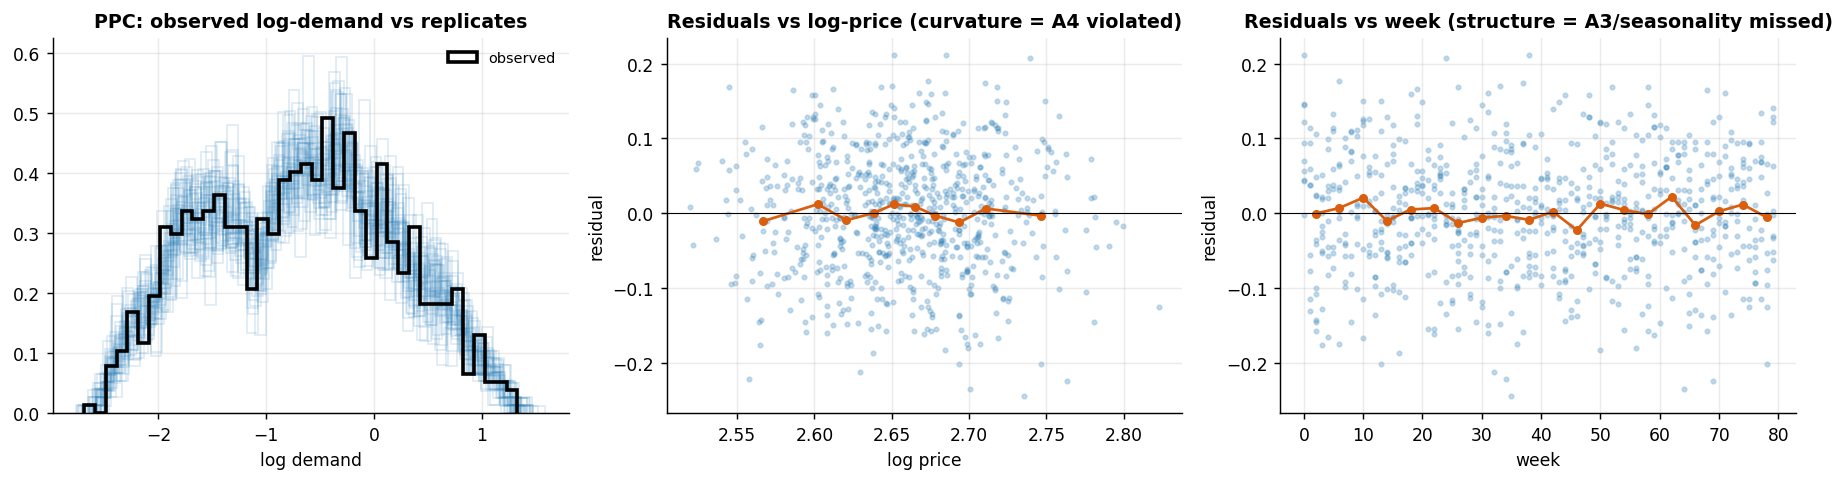

In [5]:
# Posterior predictive: thin the posterior (the plot needs ~40 replicate datasets, not thousands).
step = max(1, idata.posterior.sizes["draw"] // (60 if FAST else 200))
idata_thin = idata.sel(draw=slice(None, None, step))
with model:
    ppc = pm.sample_posterior_predictive(idata_thin, random_seed=SEED, progressbar=False)
y_rep = ppc.posterior_predictive["obs"].values.reshape(-1, len(ld))

# Posterior-mean residuals (point diagnostics; the PPC handles full-uncertainty checking)
a_hat = idata.posterior["alpha_r"].values.reshape(-1, R).mean(0)
g_hat = idata.posterior["gamma"].values.reshape(-1, z.shape[1]).mean(0)
resid = ld - (a_hat[r_idx] + partial[r_idx] * lp + z @ g_hat)
wk = df["week"].values

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
plots.ppc_plot(ax[0], ld, y_rep, title="PPC: observed log-demand vs replicates")
ax[0].set_xlabel("log demand")
qb = np.quantile(lp, np.linspace(0, 1, 11)); ib = np.clip(np.searchsorted(qb, lp, side="right") - 1, 0, 9)
ax[1].scatter(lp, resid, s=6, alpha=0.25, color=plots.BLUE)
ax[1].plot(pd.Series(lp).groupby(ib).mean().values, pd.Series(resid).groupby(ib).mean().values,
           "o-", color=plots.ORANGE, lw=1.5, ms=4)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_xlabel("log price"); ax[1].set_ylabel("residual")
ax[1].set_title("Residuals vs log-price (curvature = A4 violated)")
ax[2].scatter(wk, resid, s=6, alpha=0.25, color=plots.BLUE)
wm = pd.Series(resid).groupby(wk // 4)
ax[2].plot(wm.mean().index * 4 + 2, wm.mean().values, "o-", color=plots.ORANGE, lw=1.5, ms=4)
ax[2].axhline(0, color="k", lw=0.6); ax[2].set_xlabel("week"); ax[2].set_ylabel("residual")
ax[2].set_title("Residuals vs week (structure = A3/seasonality missed)")
fig.tight_layout()

# Formal A4 probe: pooled OLS with region dummies + controls + a curvature term in log-price.
lp_c2 = (lp - lp.mean()) ** 2
Xq = np.column_stack([np.eye(R)[r_idx], lp, lp_c2, z])
coef_q = np.linalg.lstsq(Xq, ld, rcond=None)[0]
dof = len(ld) - Xq.shape[1]
s2_q = float(((ld - Xq @ coef_q) ** 2).sum()) / dof
se_q = float(np.sqrt(s2_q * np.linalg.inv(Xq.T @ Xq)[R + 1, R + 1]))
verdict = ("consistent with zero -> constant elasticity survives in-sample"
           if abs(coef_q[R + 1]) < 2 * se_q else "SIGNIFICANT -> constant elasticity is suspect")
print(f"A4 curvature probe — coefficient on (log P − mean)²: {coef_q[R+1]:+.1f} (SE {se_q:.1f}, "
      f"t = {coef_q[R+1]/se_q:+.1f}) → {verdict}")
print("note the wide SE: with only ±5% price wiggle this test has little power far from current prices —")
print("another reason to treat any P* outside the observed range as extrapolation, not measurement.")
print(f"PPC replicate mean {y_rep.mean():.2f} vs observed {ld.mean():.2f}; replicate SD {y_rep.std():.2f} vs observed {ld.std():.2f}")

**How to read the three panels.** *Left* — the black observed log-demand density sits inside the blue
cloud of posterior replicates: the model reproduces the location, spread and shape of the outcome. *Middle*
— residuals vs log-price show no systematic bend: the binned means (orange) hug the zero line across the
observed price range, so constant elasticity is consistent with the data *where we have data*. *Right* —
residuals vs week show no leftover seasonal wave or drift; the sine/trend controls are doing their job. The
curvature probe printed under the figure makes the middle panel formal — and its wide standard error is
itself informative: with only ±5% of price variation, in-sample data can never certify the demand shape far
from current prices. **None of this validates A1 (exogeneity):** the step-8 model passes every one of
these checks while being badly wrong about the causal slope.

## 6 · Validate — recovery, shrinkage, and calibration

Estimated vs true elasticity should track the 45° line; the thin regions' point estimates get
pulled toward the fleet mean (that's pooling protecting us), and the credible intervals are
wider where data is thin. We also check that the 90% intervals actually **cover** the true
elasticities (calibration).


MAE — no pool 0.33, complete 0.27, partial 0.21  ·  coverage 67%
coverage split — thin regions (0–2): 2/3 covered · rich regions: 6/9 covered
with only 12 regions, a perfectly calibrated 90% interval covers 8 or fewer with probability 0.03 → a real shortfall, not just noise


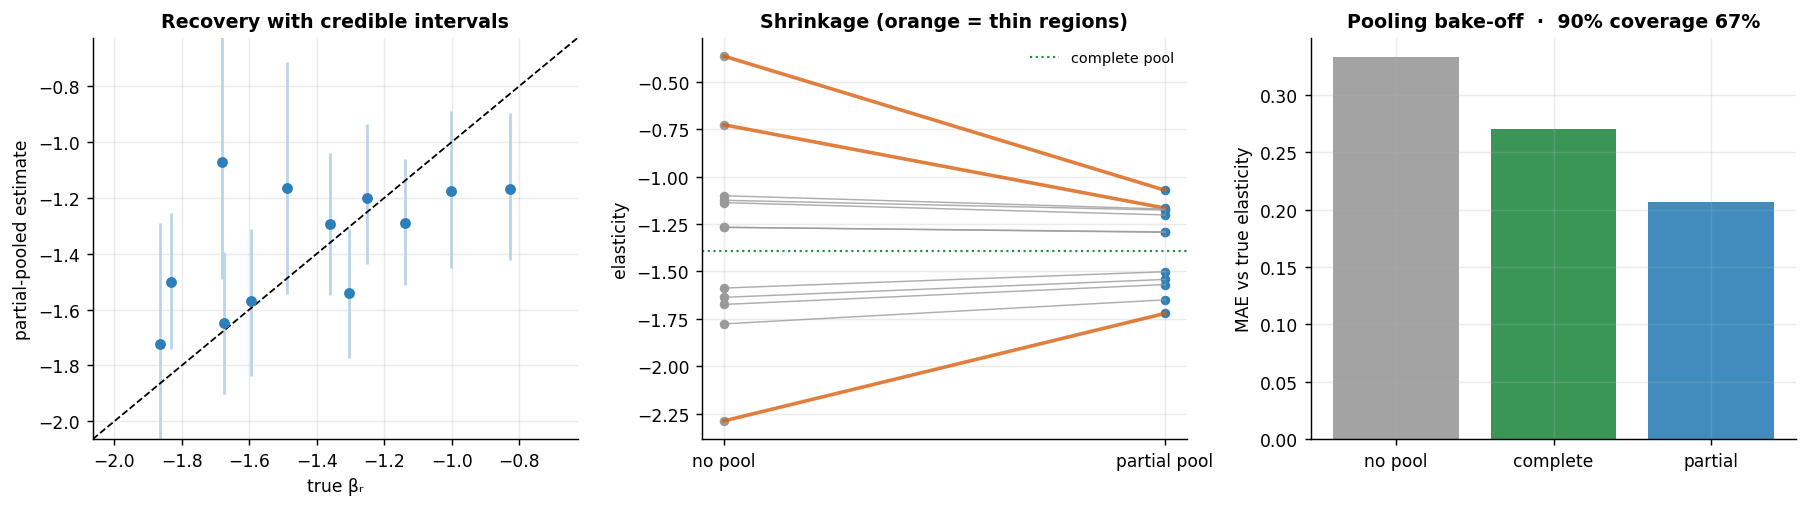

In [6]:
est_lo, est_hi = np.quantile(beta_post, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# (1) recovery with CIs (forest-style vs truth)
ax[0].errorbar(true_elast, partial, yerr=[partial-est_lo, est_hi-partial], fmt="o", color=plots.BLUE, ecolor="#b9d4e8", ms=5)
lim=[min(true_elast.min(),partial.min())-.2, max(true_elast.max(),partial.max())+.2]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("true βᵣ"); ax[0].set_ylabel("partial-pooled estimate"); ax[0].set_title("Recovery with credible intervals")
# (2) shrinkage: no-pool -> partial-pool, thin regions pulled hardest
for i in range(R):
    lw = 2.0 if i < 3 else 0.8
    ax[1].plot([0,1],[nopool[i],partial[i]], color=(plots.ORANGE if i<3 else plots.GREY), lw=lw, alpha=0.8)
ax[1].axhline(complete, color=plots.GREEN, ls=":", lw=1.2, label="complete pool")
ax[1].scatter(np.zeros(R), nopool, color=plots.GREY, s=18); ax[1].scatter(np.ones(R), partial, color=plots.BLUE, s=18)
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["no pool","partial pool"]); ax[1].set_ylabel("elasticity")
ax[1].set_title("Shrinkage (orange = thin regions)"); ax[1].legend(frameon=False, fontsize=8)
# (3) calibration + MAE
hits = (est_lo <= true_elast) & (true_elast <= est_hi)
cover = hits.mean()
mae = {"no pool": np.abs(nopool-true_elast).mean(), "complete": np.abs(complete-true_elast).mean(),
       "partial": np.abs(partial-true_elast).mean()}
ax[2].bar(list(mae.keys()), list(mae.values()), color=[plots.GREY, plots.GREEN, plots.BLUE], alpha=0.9)
ax[2].set_ylabel("MAE vs true elasticity"); ax[2].set_title(f"Pooling bake-off  ·  90% coverage {cover:.0%}")
fig.tight_layout()
print(f"MAE — no pool {mae['no pool']:.2f}, complete {mae['complete']:.2f}, partial {mae['partial']:.2f}  ·  coverage {cover:.0%}")

# Where do the interval misses live, and is the shortfall even signal? (see prose below)
thin = np.arange(R) < 3
p_asbad = stats.binom.cdf(int(hits.sum()), R, 0.90)   # P(a truly-90% method covers this few or fewer)
print(f"coverage split — thin regions (0–2): {int(hits[thin].sum())}/3 covered · rich regions: {int(hits[~thin].sum())}/9 covered")
print(f"with only {R} regions, a perfectly calibrated 90% interval covers {int(hits.sum())} or fewer with probability "
      f"{p_asbad:.2f} → {'within Monte-Carlo noise of calibrated' if p_asbad > 0.05 else 'a real shortfall, not just noise'}")

thin regions — predicted shrinkage [0.73 0.6  0.41], realized [0.71 0.61 0.7 ]
rich regions — predicted 0.25 on average, realized 0.30 (0 region(s) hidden: no-pool slope already ≈ fleet mean, so the ratio is ill-defined)


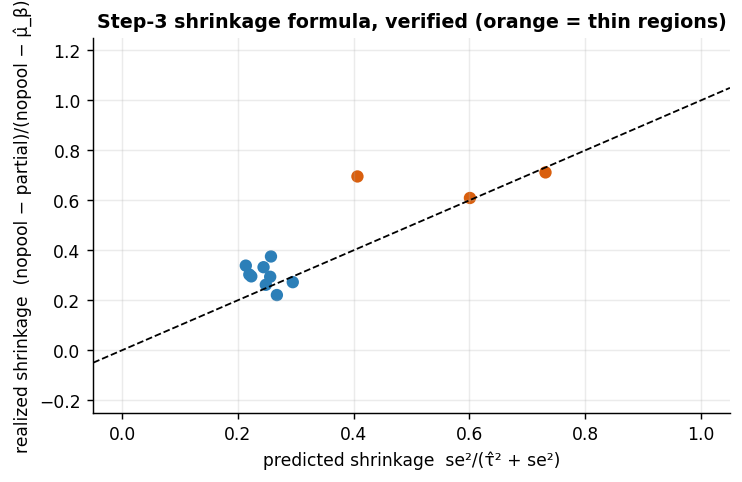

In [7]:
# Close the loop on step 3's shrinkage formula. Predicted pull toward the fleet for region r:
#   w_r = se_r^2 / (tau^2 + se_r^2)   (se_r = no-pool OLS slope standard error, tau = posterior tau_beta)
# Realized pull: how far the posterior actually moved the no-pool slope toward the fleet-level mu_beta.
tau_hat = float(idata.posterior["tau_beta"].values.mean())
mu_hat = float(idata.posterior["mu_beta"].values.mean())
se_np = np.empty(R)
for i in range(R):
    m = r_idx == i
    Xi = np.column_stack([np.ones(int(m.sum())), lp[m], z[m]])
    ci = np.linalg.lstsq(Xi, ld[m], rcond=None)[0]
    s2i = float(((ld[m] - Xi @ ci) ** 2).sum()) / (int(m.sum()) - Xi.shape[1])
    se_np[i] = np.sqrt(s2i * np.linalg.inv(Xi.T @ Xi)[1, 1])
w_pred = se_np ** 2 / (tau_hat ** 2 + se_np ** 2)
w_real = (nopool - partial) / (nopool - mu_hat)
valid = np.abs(nopool - mu_hat) > 0.05          # realized ratio is ill-defined when OLS already sits on the fleet mean

fig, ax = plt.subplots(figsize=(5.8, 3.8))
cols = np.where(np.arange(R) < 3, plots.ORANGE, plots.BLUE)
ax.scatter(w_pred[valid], w_real[valid], c=cols[valid], s=34)
ax.plot([-0.05, 1.05], [-0.05, 1.05], "k--", lw=1)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.25, 1.25)
ax.set_xlabel("predicted shrinkage  se²/(τ̂² + se²)"); ax.set_ylabel("realized shrinkage  (nopool − partial)/(nopool − μ̂_β)")
ax.set_title("Step-3 shrinkage formula, verified (orange = thin regions)")
fig.tight_layout()
print(f"thin regions — predicted shrinkage {np.round(w_pred[:3], 2)}, realized {np.round(w_real[:3], 2)}")
print(f"rich regions — predicted {w_pred[3:].mean():.2f} on average, realized {np.nanmean(np.clip(w_real[3:], -1, 2)):.2f} "
      f"({int((~valid).sum())} region(s) hidden: no-pool slope already ≈ fleet mean, so the ratio is ill-defined)")

**How to read those panels.** *Left* — partial-pooled estimates track the true elasticities along the
45° line, and the error bars are visibly wider for the thin regions (less data → more honest uncertainty).
*Middle* — the shrinkage in action: lines connect each region's noisy no-pool estimate (left) to its
partial-pooled estimate (right); the **thin regions (orange) get yanked hardest** toward the fleet, while
data-rich regions barely budge. That selective pull is exactly the protection partial pooling buys. *Right*
— the bottom line: mean absolute error against the truth is **lowest for partial pooling**, beating both
extremes *even now that the baselines get the same controls* — no-pooling is noisy, complete-pooling is
biased, and the remaining gap is the pooling choice alone.

**Is the below-nominal coverage a bug?** Don't wave it away — check it, twice; both checks are printed
under the figure. The **split** locates any misses: shrinkage intervals are calibrated for the
*ensemble*, not for each pre-shrinkage slope, so intervals run too narrow precisely for regions whose
true elasticity sits far from the fleet mean and for the hard-shrunk thin ones. The **binomial line**
asks whether the shortfall is even signal: with 12 regions, a perfectly calibrated 90% procedure still
misses a couple regularly, and the printed probability says on which side of that line this run falls.
When it flags a *real* shortfall, that is the known price of shrinkage — slightly overconfident
**per-region** intervals bought in exchange for the best **point** estimates (lowest MAE, right panel) —
worth knowing before quoting an interval to a region manager, and one more reason the decision rules in
step 7 lean on $P(\beta_r < -1)$ across the whole posterior rather than on interval endpoints. The
follow-up scatter then closes the loop on step 3's shrinkage formula: the predicted pull
$se_r^2/(\hat\tau_\beta^2+se_r^2)$ — which is exactly the step-3 factor rewritten, since $se_r$ stands in for $\sqrt{\sigma^2/n_r}$ and $1-\tau^2/(\tau^2+se^2)=se^2/(\tau^2+se^2)$ — tracks the pull the posterior actually applied (45° line), thin
regions (orange) toward the heavy-shrinkage corner — the formula we asked you to trust in step 3 is the
formula the sampler obeyed.

## 7 · Decide, in euros — profit-maximising price per region

The decision-maker's question is not "what is $\beta$?" but "**what price do I set?**" For
constant-elasticity demand $Q(P) = A P^{\beta}$ and constant marginal cost $c$, weekly profit is

$$
\pi(P) \;=\; (P - c)\, Q(P) \;=\; (P - c)\, A P^{\beta}.
$$

Differentiate and set to zero:

$$
\frac{d\pi}{dP} \;=\; A P^{\beta} \;+\; (P - c)\,\beta A P^{\beta-1}
\;=\; A P^{\beta-1}\big[(\beta+1)\,P \;-\; \beta c\big] \;=\; 0
\quad\Longrightarrow\quad
P^\star \;=\; \frac{\beta}{\beta+1}\, c ,
$$

valid **only when $\beta < -1$** (demand elastic). The bracket $(\beta+1)P - \beta c$ then starts positive
at small $P$ and decreases through zero — profit rises, peaks at $P^\star$, falls: a genuine maximum
(that sign change *is* the second-order condition). For $-1 \le \beta < 0$ the bracket stays positive for
every $P>0$, so the model says "raise price without limit" — which really means *the constant-elasticity
model has left its domain of validity*, not that infinite prices are optimal.

Rearranged, $P^\star$ is the classic **Lerner index** (markup) rule:

$$
\frac{P^\star - c}{P^\star} \;=\; -\frac{1}{\beta}
$$

— *optimal markup over cost equals the inverse elasticity*, the oldest one-liner in pricing: $\beta=-2$
prices at twice cost, $\beta=-1.5$ at three times cost. And note the **blow-up as $\beta \to -1^{-}$**:
the denominator $\beta+1 \to 0^-$ and $P^\star \to +\infty$. Posterior draws near $-1$ therefore produce
wild optimal prices — the statistical reason (exploited below) why regions whose elasticity posterior
straddles $-1$ get routed to a **controlled test**, not a price move.

We propagate the **elasticity posterior** draw-by-draw into a **price posterior** and a **profit-uplift
posterior** per region, and — the honest part — flag regions where we're not confident demand is even
elastic ($\beta<-1$) for that test rather than acting on a shaky slope.

   region  elasticity  P(elastic) P* €     P* 90% CI  uplift %          action
region_00       -1.07        0.63    —             —        35 controlled test
region_01       -1.72        1.00 19.6  [14.3, 35.6]        12       set price
region_02       -1.17        0.75    —             —        35 controlled test
region_03       -1.20        0.88    —             —        44 controlled test
region_04       -1.18        0.85    —             —        43 controlled test
region_05       -1.29        0.97 34.4 [22.6, 109.8]        36       set price
region_06       -1.57        1.00 22.2  [17.6, 33.7]        16       set price
region_07       -1.65        1.00 20.3  [16.9, 28.3]        11       set price
region_08       -1.29        0.98 35.1 [23.6, 100.9]        37       set price
region_09       -1.17        0.85    —             —        45 controlled test
region_10       -1.54        1.00 22.7  [18.3, 33.8]        17       set price
region_11       -1.50        1.00 24.0  [18.8, 39.4]

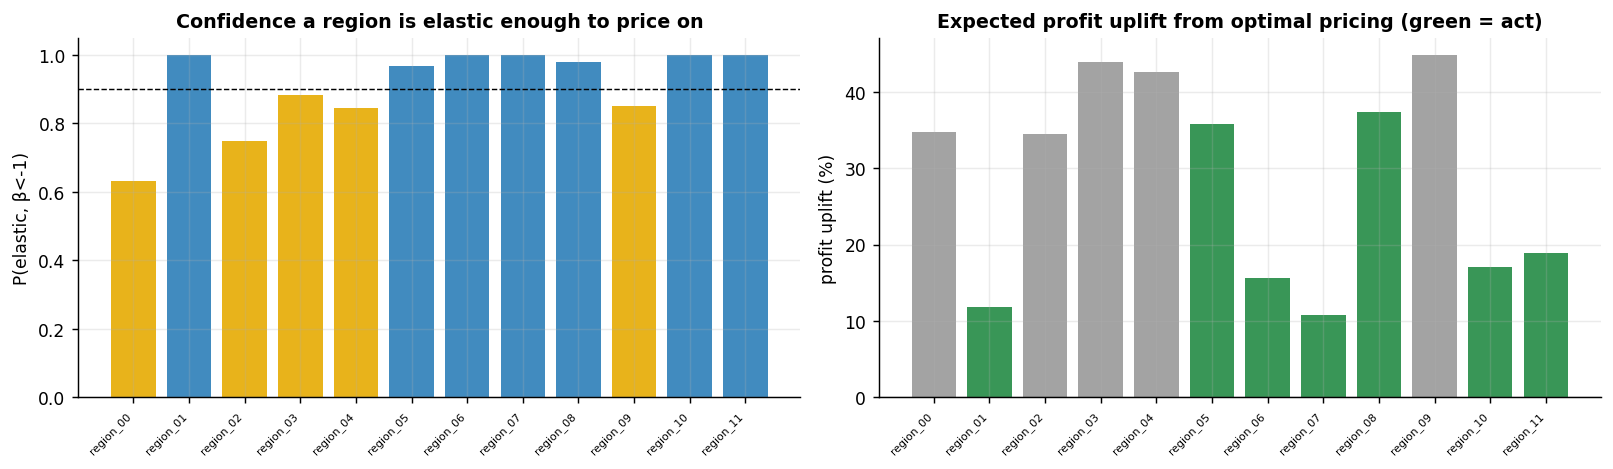

In [8]:
MARGINAL_COST = 8.0
p_elastic = (beta_post < -1).mean(0)                                   # P(region is elastic, beta<-1)
P0 = df.groupby("region")["price"].mean().reindex(regions).values      # current price per region
Q0 = df.groupby("region")["demand"].mean().reindex(regions).values     # current weekly quantity (a normalized index)

# Per posterior DRAW so elasticity, optimal price and profit uplift stay consistent (the naive version
# mixed an unconditional-mean elasticity with a conditional-on-elastic optimal price). Monopoly optimum
# under constant-elasticity demand is P* = c*beta/(beta+1) for beta<-1; profit(P)=(P-c)*Q0*(P/P0)**beta.
# We report the uplift as a %% of current profit — scale-free, so it does not depend on the demand units.
def uplift_pct(beta, p0, c=MARGINAL_COST):
    elastic = beta < -1.001
    pstar = np.where(elastic, c * beta / (beta + 1.0), p0)
    ratio = ((pstar - c) * (pstar / p0) ** beta) / (p0 - c)             # profstar/prof0 (Q0 cancels)
    return np.where(elastic, 100.0 * (ratio - 1.0), 0.0)               # act only where elastic, else 0%%

def pstar_q(b, c=MARGINAL_COST, qs=(0.05, 0.5, 0.95)):
    b_el = b[b < -1.001]                                                # the formula's domain: elastic draws only
    return np.quantile(c * b_el / (b_el + 1.0), qs)

rows = []; fleet_pct = []
for i in range(R):
    up = uplift_pct(beta_post[:, i], P0[i]); conf = float((beta_post[:, i] < -1).mean())
    act = "set price" if conf > 0.9 else ("controlled test" if conf > 0.5 else "hold/test")
    if conf > 0.9:
        ps = pstar_q(beta_post[:, i])
        pstar_med, pstar_ci = f"{ps[1]:.1f}", f"[{ps[0]:.1f}, {ps[2]:.1f}]"
    else:                                                              # no price published for test-routed regions
        pstar_med, pstar_ci = "—", "—"
    if conf > 0.9: fleet_pct.append(up)
    # P(uplift>0) equals P(elastic) by construction (P* is the profit optimum), so it is
    # not repeated as a column -- keeps each printed row inside the page width.
    rows.append({"region": regions[i], "elasticity": round(partial[i], 2), "P(elastic)": round(conf, 2),
                 "P* €": pstar_med, "P* 90% CI": pstar_ci,
                 "uplift %": round(float(up.mean())), "action": act})
tbl = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.7))
ax[0].bar(range(R), p_elastic, color=[plots.BLUE if c_>0.9 else (plots.GOLD if c_>0.5 else plots.ORANGE) for c_ in p_elastic], alpha=0.9)
ax[0].axhline(0.9, color="k", ls="--", lw=0.8); ax[0].set_xticks(range(R)); ax[0].set_xticklabels(regions, rotation=45, ha="right", fontsize=6)
ax[0].set_ylabel("P(elastic, β<-1)"); ax[0].set_title("Confidence a region is elastic enough to price on")
up_means = [float(uplift_pct(beta_post[:, i], P0[i]).mean()) for i in range(R)]
ax[1].bar(range(R), up_means, color=[plots.GREEN if p_elastic[i]>0.9 else plots.GREY for i in range(R)], alpha=0.9)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_xticks(range(R)); ax[1].set_xticklabels(regions, rotation=45, ha="right", fontsize=6)
ax[1].set_ylabel("profit uplift (%)"); ax[1].set_title("Expected profit uplift from optimal pricing (green = act)")
fig.tight_layout()
print(tbl.to_string(index=False))
fleet = np.mean(fleet_pct, axis=0) if fleet_pct else np.zeros(beta_post.shape[0])
print(f"\nAcross the {len(fleet_pct)} confidently-elastic regions, moving to optimal pricing lifts profit by "
      f"{fleet.mean():+.0f}%\n[90% {np.quantile(fleet,.05):+.0f}%, {np.quantile(fleet,.95):+.0f}%] on average — the pricing "
      f"change's value, scale-free and with uncertainty carried through (assumes constant elasticity out to P*; see caveats).")

# The Jensen/boundary illustration the prose below leans on — computed, never asserted:
weak_i = int(np.argmin(p_elastic)); strong_i = int(np.argmax(p_elastic))
bmean = float(beta_post[:, weak_i].mean())
plug = MARGINAL_COST * bmean / (bmean + 1.0)
plug_txt = f"€{plug:.0f}" if bmean < -1 else f"€{plug:.0f} (formula already outside its β<−1 domain)"
pstar_strong = float(pstar_q(beta_post[:, strong_i])[1])
up_w = uplift_pct(beta_post[:, weak_i], P0[weak_i]); conf_w = float((beta_post[:, weak_i] < -1).mean())
print(f"\npoint-plug illustration — weakest region {regions[weak_i]}: P(elastic) = {conf_w:.2f}, mean β = {bmean:.2f};")
print(f"plugging that mean into P* = cβ/(β+1) gives {plug_txt}, vs €{pstar_strong:.0f} for the most confident region ({regions[strong_i]}).")
print(f"its expected uplift {up_w.mean():+.0f}% is diluted by the {1-conf_w:.0%} of draws pinned at 0%; conditional on truly")
print(f"being elastic it is {up_w.mean()/max(conf_w, 1e-9):+.0f}% — a big, *unreliable* number, which is exactly why it goes to a test.")

Green band = prices ever charged; the model was only ever tested there (step 5). Both P₀ (dotted) and the
median P* (orange) matter less than the SHAPE: a flat top means a mis-estimated β costs little profit;
curves that fan out and keep rising off the right edge mean the 'optimum' is an extrapolated guess.


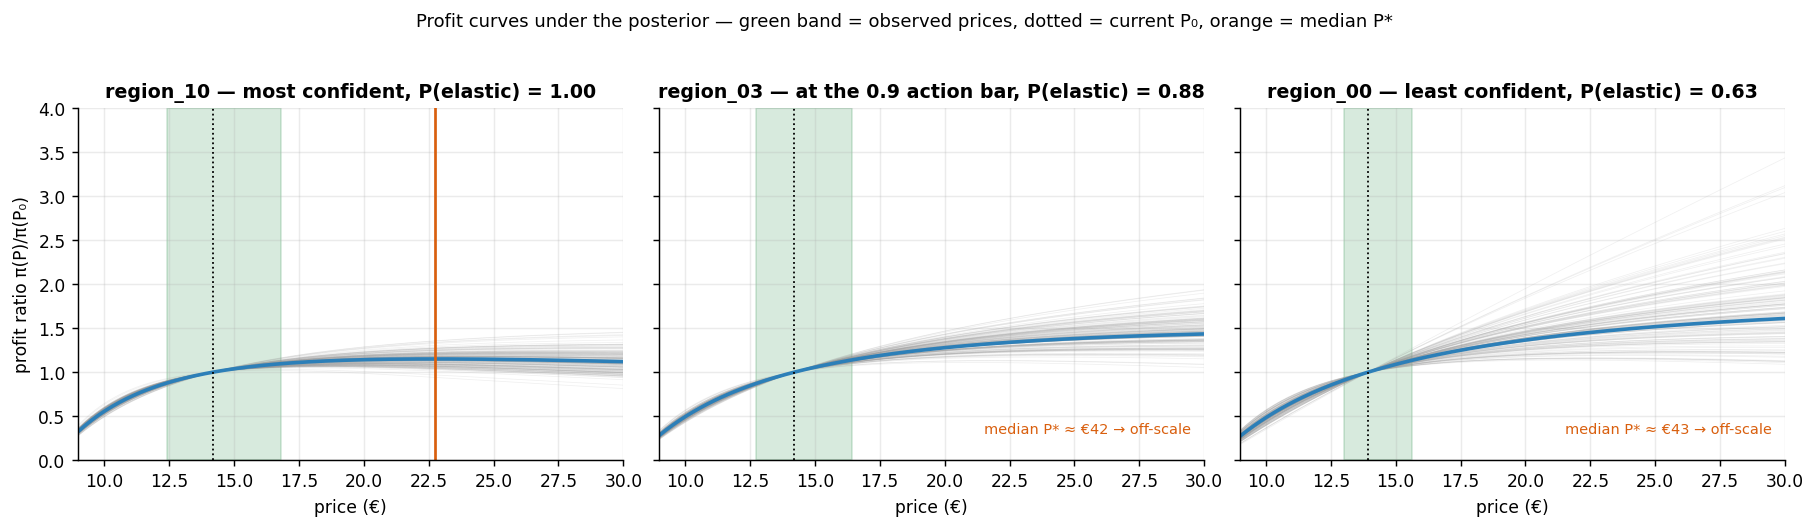

In [9]:
# Profit-ratio curves pi(P)/pi(P0) for three representative regions: the most confident, one sitting
# at the 0.9 action bar, and the least confident. Grey = individual posterior draws (each one a full profit curve), blue = the posterior-median
# curve, green band = the price range we actually OBSERVED — everything outside it rides on the
# constant-elasticity assumption (A4) alone.
pr_range = df.groupby("region")["price"].agg(["min", "max"])
order = np.argsort(p_elastic)
picks = [int(order[-1]), int(np.argmin(np.abs(p_elastic - 0.9))), int(order[0])]
labels = ["most confident", "at the 0.9 action bar", "least confident"]
if len(set(picks)) < 3:                     # degenerate posterior ordering: fall back to spread picks
    picks = [int(order[-1]), int(order[R // 2]), int(order[0])]
Pgrid = np.linspace(9.0, 30.0, 160)
n_show = 150 if FAST else 300
sel = np.random.default_rng(SEED).choice(beta_post.shape[0], size=min(n_show, beta_post.shape[0]), replace=False)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9), sharey=True)
for k, (i, lab) in enumerate(zip(picks, labels)):
    p0 = P0[i]
    curves = (Pgrid[None, :] - MARGINAL_COST) * (Pgrid[None, :] / p0) ** beta_post[sel, i][:, None] / (p0 - MARGINAL_COST)
    med = (Pgrid - MARGINAL_COST) * (Pgrid / p0) ** float(np.median(beta_post[:, i])) / (p0 - MARGINAL_COST)
    ax[k].plot(Pgrid, curves.T, color=plots.GREY, lw=0.4, alpha=0.15)
    ax[k].plot(Pgrid, med, color=plots.BLUE, lw=2)
    ax[k].axvspan(pr_range.loc[regions[i], "min"], pr_range.loc[regions[i], "max"], color=plots.GREEN, alpha=0.18)
    ax[k].axvline(p0, color="k", ls=":", lw=1)
    if p_elastic[i] > 0.5:
        ps_med = float(pstar_q(beta_post[:, i])[1])
        if ps_med <= Pgrid.max():           # keep panels on a common, comparable price axis
            ax[k].axvline(ps_med, color=plots.ORANGE, lw=1.5)
        else:
            ax[k].annotate(f"median P* ≈ €{ps_med:.0f} → off-scale", xy=(Pgrid.max() - 0.5, 0.3),
                           ha="right", fontsize=8, color=plots.ORANGE)
    ax[k].set_xlim(Pgrid.min(), Pgrid.max())
    ax[k].set_ylim(0, 4); ax[k].set_xlabel("price (€)")
    ax[k].set_title(f"{regions[i]} — {lab}, P(elastic) = {p_elastic[i]:.2f}")
ax[0].set_ylabel("profit ratio π(P)/π(P₀)")
fig.suptitle("Profit curves under the posterior — green band = observed prices, dotted = current P₀, orange = median P*",
             y=1.03, fontsize=10)
fig.tight_layout()
print("Green band = prices ever charged; the model was only ever tested there (step 5). Both P₀ (dotted) and the")
print("median P* (orange) matter less than the SHAPE: a flat top means a mis-estimated β costs little profit;")
print("curves that fan out and keep rising off the right edge mean the 'optimum' is an extrapolated guess.")

**How to read the decision table and the two panels.** *Left* — each bar is $P(\beta<-1)$, our
posterior confidence that a region's demand is **elastic** enough to price on: **blue** clears the 0.9
line (*set price*), **gold** sits in 0.5–0.9 (*controlled test*), **orange** is below 0.5 (*hold/test*).
*Right* — the expected **profit uplift** from moving to the optimal price, **green** only where we are
confident enough to act. The fleet number underneath averages the uplift across the confidently-elastic
regions and carries the posterior through to a 90% interval. The **P\*** columns are the number the CMO
actually signs: the posterior-median optimal price with its 90% credible interval — printed *only* for
regions confident enough to act on ("—" elsewhere: publishing a price for a region we just routed to a
test would invite exactly the mistake this notebook is built to prevent).

**One subtlety worth saying out loud** — the kind a sharp audience member will probe. The "profit uplift %"
is a **posterior mean over *every* draw**, with the non-elastic draws ($\beta\ge-1$, where raising price
doesn't pay) contributing **0%**. So it is an *expected* uplift already discounted by our uncertainty — not
"the uplift once we act". For the confident **set price** rows ($P(\text{elastic})\approx 1$) the two
coincide; for the weakest region — see the *point-plug illustration* printed under the table — the expected
uplift is diluted by the slice of draws worth 0%, and the uplift *conditional on the region truly being
elastic* (also printed) is far larger and far shakier.

This is also why you **cannot reproduce the uplift column by plugging the row's own elasticity into the
formula.** The closed form $P^\star=c\,\beta/(\beta+1)$ blows up as $\beta\to-1^-$: the printed
illustration plugs the weakest region's *mean* elasticity into the formula and gets an absurd price, a
world away from the sane optima of the well-elastic regions. So the per-draw uplift has a heavy right tail
and its **mean is not the formula evaluated at the mean elasticity** (**Jensen's inequality** — for a curved function the average of the outputs is not the function of the average input; here $P^\star$ bends so sharply near $\beta=-1$ that the mean of the per-draw uplifts sits well above the uplift computed at the mean $\beta$). We deliberately propagate the *whole* posterior rather than point-plug a single slope — and
that very instability near $\beta=-1$ is the statistical reason those low-confidence regions are routed to
a **controlled test**, not to a price move we might regret.

**The profit curves make the same point visually.** In the *most confident* panel the grey posterior
curves agree on a gentle hill with a **flat top**: even a sizeable error in $\beta$ moves profit little
near $P^\star$, so acting is low-risk. In the *least confident* panel the curves fan out and many keep
rising off the right edge — the model is begging for a price far outside the green band of prices we have
ever charged, on a functional form (A4) we could only test *inside* that band; statistical risk and
extrapolation risk stack, so it goes to a test. The *middle* panel sits near the 0.9 action bar and is the
boundary case the thresholds are built around: most draws agree on a gentle hill, but a visible minority
still explode off to the right — whether it clears the bar is decided by the printed $P(\beta<-1)$, and
standing this close to the threshold is itself an argument for measuring before committing. And notice one sobering detail: even for confident regions
$P^\star$ typically sits *above* the observed price band — the recommendation itself is an extrapolation.
That is why a staged rollout (move a minority of stores first, watch a few weeks) beats a fleet-wide
overnight change even where the posterior is sure.

### The cost assumption — the other number in the formula

$P^\star = c\,\beta/(\beta+1)$ is **linear in marginal cost $c$**: a ±25% error in $c$ moves *every*
recommended price by ±25%, no posterior required. Cost is usually handed to the analyst as a single
accounting number, and it deserves the same scepticism as the elasticity — arguably more, because nothing
in the data can check it. Below we sweep $c$ ±25% around our €8 and recompute the whole decision layer.
Two things to watch: the **action routing never changes** (it keys off $P(\beta<-1)$, which involves no
$c$), but every $P^\star$ and every uplift number moves — so if finance restates the cost, the
*set-vs-test split* survives while the price list is rewritten wholesale. Cost measurement is as
decision-critical as the elasticity itself.

In [10]:
cost_grid = np.array([6.0, 7.0, 8.0, 9.0, 10.0]) if FAST else np.round(np.linspace(6.0, 10.0, 9), 1)
set_idx = [i for i in range(R) if p_elastic[i] > 0.9]
rows_c = []
for c_ in cost_grid:
    fleet_c = np.mean([uplift_pct(beta_post[:, i], P0[i], c=c_) for i in set_idx], axis=0)
    med_ps = [float(pstar_q(beta_post[:, i], c=c_)[1]) for i in set_idx]
    rows_c.append({"marginal cost €": c_, "n set-price": len(set_idx),
                   "median P* range €": f"{min(med_ps):.1f}–{max(med_ps):.1f}",
                   "fleet uplift %": round(float(fleet_c.mean())),
                   "uplift 90% CI": f"[{np.quantile(fleet_c, .05):+.0f}%, {np.quantile(fleet_c, .95):+.0f}%]"})
print(pd.DataFrame(rows_c).to_string(index=False))
print("\nreading it: the set-price roster is c-invariant by construction (column 2 never moves), and every")
print("median P* scales exactly linearly in c — get the cost 25% wrong and every recommended price is 25% wrong,")
print("with the uplift estimate moving too. Before signing the price list, audit the cost number.")

 marginal cost €  n set-price median P* range €  fleet uplift % uplift 90% CI
             6.0            7         14.7–26.3               6   [+2%, +11%]
             7.0            7         17.1–30.7              12   [+6%, +19%]
             8.0            7         19.6–35.1              21  [+13%, +30%]
             9.0            7         22.0–39.5              36  [+25%, +49%]
            10.0            7         24.5–43.9              59  [+44%, +76%]



reading it: the set-price roster is c-invariant by construction (column 2 never moves), and every
median P* scales exactly linearly in c — get the cost 25% wrong and every recommended price is 25% wrong,
with the uplift estimate moving too. Before signing the price list, audit the cost number.


## 8 · Caveats — what partial pooling does *not* fix

Partial pooling handles *noise*, not *bias*. If price is endogenous to an **unobserved** demand shock,
adjusting for observed $Z$ isn't enough and the elasticity is biased **toward zero** — by step 3's OVB
formula, $\hat\beta \to \beta + \kappa\sigma_u^2/(\kappa^2\sigma_u^2 + \sigma_\nu^2)$. We now do three
things: **(i)** switch the hidden shock on at the demo strength $\kappa=1.2$ and refit the full
hierarchical model, checking the observed bias against the formula; **(ii)** sweep $\kappa$ to map the
whole bias curve — a range, not an anecdote; **(iii)** deliver the promised **preview of the IV cure**.
(These re-runs use the **full** panel, not the thinned subset used above — which only sharpens the fleet
estimate and doesn't change the bias point being made.)

clean fleet elasticity -1.36 (true -1.42)
endogenous fleet elasticity -0.59 (true -1.42) → biased toward zero by +0.83
OVB formula check — predicted bias +0.83 vs observed +0.83: the bias is computable, not mysterious.
endogenous-fit convergence: max r-hat 1.010 - min ESS 857 - divergences 0
Fix = an instrument (a cost shifter) or a natural price experiment — previewed below, full treatment in notebook 11.


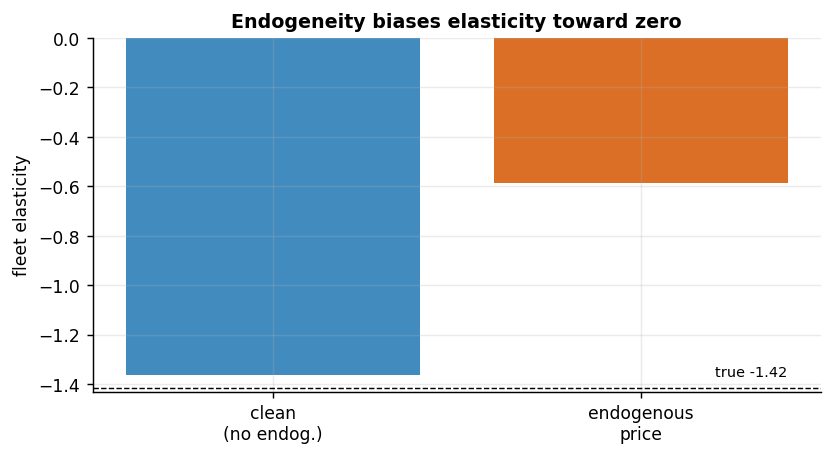

In [11]:
df2, true2 = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=1.2, seed=SEED)
lp2 = np.log(df2["price"].values); ld2 = np.log(df2["demand"].values)
r2 = df2["region"].map({r:i for i,r in enumerate(regions)}).values
z2 = df2[["competitor_price","season","trend"]].values; z2=(z2-z2.mean(0))/z2.std(0)
with pm.Model():
    mb=pm.Normal("mb",-1,1); tb=pm.HalfNormal("tb",1); br=pm.Normal("br",mb,tb,shape=R)
    ar=pm.Normal("ar",0,5,shape=R); g=pm.Normal("g",0,2,shape=3); s=pm.HalfNormal("s",1)
    pm.Normal("o", mu=ar[r2]+br[r2]*lp2+z2@g, sigma=s, observed=ld2)
    id2=pm.sample(random_seed=SEED,progressbar=False,**FIT)
biased = id2.posterior["br"].values.reshape(-1,R).mean(0)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(["clean\n(no endog.)","endogenous\nprice"], [partial.mean(), biased.mean()], color=[plots.BLUE, plots.ORANGE], alpha=0.9)
ax.axhline(true_elast.mean(), color="k", ls="--", lw=0.8); ax.text(1.4, true_elast.mean()+0.05, f"true {true_elast.mean():.2f}", ha="right", fontsize=8)
ax.set_ylabel("fleet elasticity"); ax.set_title("Endogeneity biases elasticity toward zero"); fig.tight_layout()
print(f"clean fleet elasticity {partial.mean():.2f} (true {true_elast.mean():.2f})")
obs_bias = float(biased.mean() - true2.mean())
print(f"endogenous fleet elasticity {biased.mean():.2f} (true {true2.mean():.2f}) → biased toward zero by {obs_bias:+.2f}")
# Verify step 3's OVB arithmetic: kappa=1.2, sigma_u=1, sigma_nu=0.05 — all planted in the DGP.
kappa_demo, sig_nu = 1.2, 0.05
pred_bias = kappa_demo / (kappa_demo**2 + sig_nu**2)
print(f"OVB formula check — predicted bias +{pred_bias:.2f} vs observed {obs_bias:+.2f}: the bias is computable, not mysterious.")
print(f"endogenous-fit convergence: {est.convergence_report(id2)['summary']}")
print("Fix = an instrument (a cost shifter) or a natural price experiment — previewed below, full treatment in notebook 11.")

**From a point to a curve.** One $\kappa$ is an anecdote. Below we sweep the endogeneity strength from 0
to 1.25 — regenerating the panel and re-estimating the fleet elasticity at each value (a
controls-included pooled OLS with region intercepts stands in for the full hierarchical refit: it agrees
with it at the $\kappa=1.2$ point above and costs milliseconds instead of minutes) — and overlay the OVB
*prediction* from step 3. Watch two things. **(i)** The estimate does not drift gently: because the
exogenous price wiggle is tiny ($\sigma_\nu = 0.05$), even a faint hidden shock swamps it — the bias term
$\kappa\sigma_u^2/(\kappa^2\sigma_u^2+\sigma_\nu^2)$ peaks near $\kappa\approx\sigma_\nu$ — and the
fitted "demand curve" actually slopes *upward* over a whole range of $\kappa$. **(ii)** The recommendation
flips almost immediately: the moment the estimate crosses the $\beta=-1$ decision line, "set optimal
prices in elastic regions" becomes "demand looks inelastic — hold everywhere". Endogeneity doesn't just
shade the number; it reverses the pricing call.

estimated fleet elasticity by κ:  κ=0: -1.45 · κ=0.02: +5.11 · κ=0.05: +7.98 · κ=0.1: +6.31 · κ=0.2: +3.22 · κ=0.4: +1.02 · κ=0.7: -0.01 · κ=1: -0.43 · κ=1.25: -0.63
the estimate is already on the wrong side of β=−1 by κ ≈ 0.02: a hidden shock explaining only ~14% of residual price variance flips the pricing call fleet-wide.
the grey dashed curve is step 3's OVB formula — theory and refit agree across the whole sweep,
including the perverse region where the fitted demand curve slopes upward.


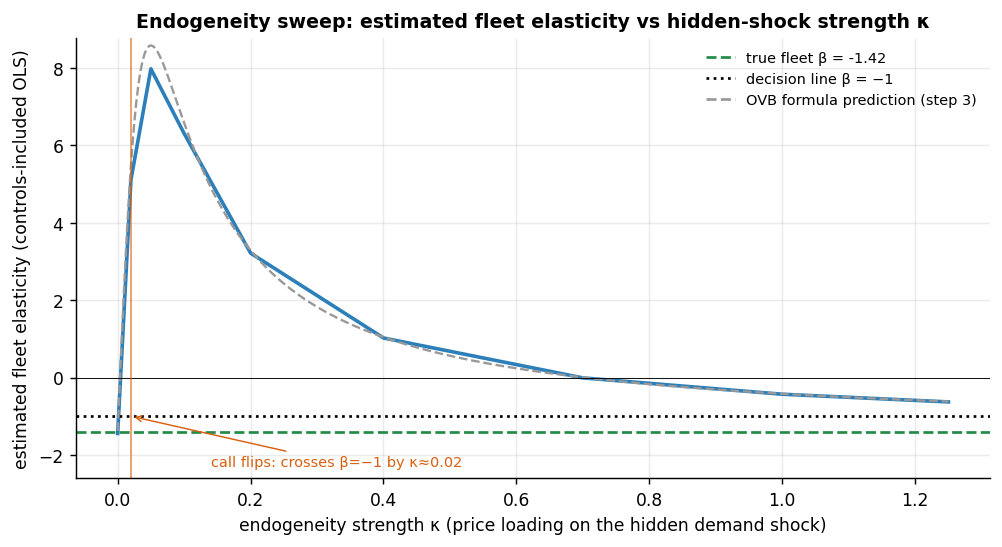

In [12]:
kappas = (np.array([0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0, 1.25]) if FAST
          else np.concatenate([[0.0], np.geomspace(0.01, 1.25, 20)]))

def fleet_ols(kappa):
    d, _ = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=float(kappa), seed=SEED)
    lpk, ldk = np.log(d["price"].values), np.log(d["demand"].values)
    rk = d["region"].map({r: i for i, r in enumerate(regions)}).values
    zk = d[["competitor_price", "season", "trend"]].values; zk = (zk - zk.mean(0)) / zk.std(0)
    return float(np.linalg.lstsq(np.column_stack([np.eye(R)[rk], lpk, zk]), ldk, rcond=None)[0][R])

betas_k = np.array([fleet_ols(k) for k in kappas])
sig_nu = 0.05
kfine = np.linspace(1e-4, kappas.max(), 400)
ovb_pred = true_elast.mean() + kfine / (kfine**2 + sig_nu**2)          # step-3 formula, sigma_u = 1
cross = float(kappas[np.argmax(betas_k > -1.0)]) if np.any(betas_k > -1.0) else float("nan")

fig, ax = plt.subplots(figsize=(7.8, 4.3))
plots.sensitivity_plot(ax, kappas, betas_k, true_elast.mean(), -1.0, tipping=None,
                       title="Endogeneity sweep: estimated fleet elasticity vs hidden-shock strength κ")
ax.plot(kfine, ovb_pred, color=plots.GREY, ls="--", lw=1.3)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(cross, color=plots.ORANGE, lw=0.9, alpha=0.7)
ax.set_ylim(min(betas_k.min(), -2.6), betas_k.max() + 0.8)
ax.annotate(f"call flips: crosses β=−1 by κ≈{cross:g}", xy=(cross, -1.0), xytext=(cross + 0.12, -2.3),
            fontsize=8, color=plots.ORANGE, arrowprops=dict(arrowstyle="->", color=plots.ORANGE, lw=0.8))
ax.set_xlabel("endogeneity strength κ (price loading on the hidden demand shock)")
ax.set_ylabel("estimated fleet elasticity (controls-included OLS)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles + [plt.Line2D([], [], color=plots.GREY, ls="--")],
          [f"true fleet β = {true_elast.mean():.2f}", "decision line β = −1", "OVB formula prediction (step 3)"],
          frameon=False, fontsize=8)
fig.tight_layout()
print("estimated fleet elasticity by κ:  " + " · ".join(f"κ={k:g}: {b:+.2f}" for k, b in zip(kappas, betas_k)))
print(f"the estimate is already on the wrong side of β=−1 by κ ≈ {cross:g}: a hidden shock explaining only "
      f"~{cross**2/(cross**2 + sig_nu**2):.0%} of residual price variance flips the pricing call fleet-wide.")
print("the grey dashed curve is step 3's OVB formula — theory and refit agree across the whole sweep,")
print("including the perverse region where the fitted demand curve slopes upward.")

### The cure, previewed — an instrumental variable

The fix for a hidden shock sitting in *both* equations is a variable that moves **price** but has **no
path to demand except through price** — an **instrument** $W$. The textbook pricing instrument is a
**cost shifter**: a wholesale-cost or exchange-rate shock moves what we charge, but shoppers never see it
except in the price tag. $W$ must satisfy three conditions:

- **Relevance:** $\mathrm{Cov}(W, \log P) \neq 0$ — checked below via the first-stage F-statistic — the **F** measures how strongly the instrument moves price once the controls are partialled out, so a big F means the cost shock leaves plenty of clean price variation to work with
  (Stock–Yogo rule of thumb: $F < 10$ = too weak to use, and a weak instrument is *worse* than none);
- **Exclusion:** $W$ affects $\log Q$ *only through* $\log P$ — untestable, argued from institutions
  (customers don't observe our wholesale costs);
- **Independence:** $W \perp u$ — cost shocks don't chase demand shocks.

**Two-stage least squares (2SLS)** then uses *only the $W$-driven slice of price variation*:

$$
\text{stage 1: } \widehat{\log P} \;=\; \hat\pi_0 + \hat\pi_1 W + \hat\pi_Z^\top Z, \qquad
\text{stage 2: } \log Q \;=\; \alpha + \beta_{\mathrm{IV}}\, \widehat{\log P} + \gamma^\top Z + e .
$$

The endogenous slice of price ($\kappa u$) is orthogonal to $W$, so stage 1 filters it out and
$\beta_{\mathrm{IV}}$ recovers the causal slope. `dgp.price_panel` has no instrument built in, so we plant
one on the $\kappa=1.2$ panel by hand: a cost shock $W_{rt} \sim \mathcal N(0,1)$ that shifts log-price by
$0.25\,W_{rt}$ and shifts log-demand **only through that price move** (by $\beta_r \times$ the price
shift) — exclusion true by construction.

first-stage F = 28 (>10: relevant, not weak)
naive OLS: -0.63 ± 0.01 — a tight band 67 SEs from the truth -1.42 (precisely wrong)
2SLS:      -1.66 ± 0.21 — a wide band 1.1 SEs from the truth (imprecisely right)
2SLS keeps only the cost-driven slice of price variation, so the hidden-shock slice drops out of the estimate.
Full treatment — robust SEs, weak-instrument diagnostics, Bayesian IV: notebook 11, and 11b on real Criteo data.


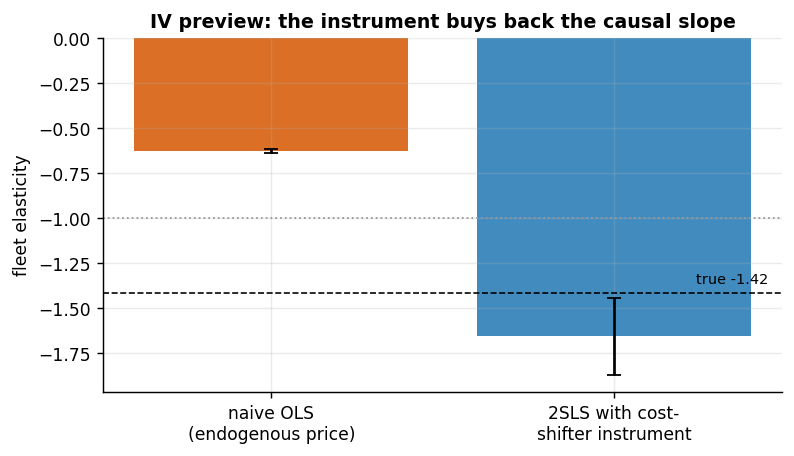

In [13]:
W = np.random.default_rng(SEED + 100).normal(size=len(lp2))
shift = 0.25 * W                                # cost passthrough into log-price (the stage-1 relevance)
lp_iv = lp2 + shift                             # price moves with the cost shock...
ld_iv = ld2 + true2[r2] * shift                 # ...and demand responds ONLY through price: exclusion by construction
Dm = np.eye(R)[r2]

# naive OLS on the endogenous panel (with controls + region intercepts), and its classical SE
X_ols = np.column_stack([Dm, lp_iv, z2])
coef_o = np.linalg.lstsq(X_ols, ld_iv, rcond=None)[0]
beta_ols = float(coef_o[R])
s2_o = float(((ld_iv - X_ols @ coef_o) ** 2).sum()) / (len(ld_iv) - X_ols.shape[1])
se_ols = float(np.sqrt(s2_o * np.linalg.inv(X_ols.T @ X_ols)[R, R]))

# stage 1: log-price on instrument + exogenous controls -> keep only the clean, W-driven variation
X_s1 = np.column_stack([Dm, W, z2])
lp_hat = X_s1 @ np.linalg.lstsq(X_s1, lp_iv, rcond=None)[0]
F1 = est.first_stage_F(W, lp_iv)
# stage 2: demand on the FITTED log-price; the proper 2SLS SE uses stage-2 coefficients with
# residuals computed at the ACTUAL price (the textbook correction to naive two-step OLS output)
X_s2 = np.column_stack([Dm, lp_hat, z2])
coef2 = np.linalg.lstsq(X_s2, ld_iv, rcond=None)[0]
beta_iv = float(coef2[R])
resid_iv = ld_iv - np.column_stack([Dm, lp_iv, z2]) @ coef2
s2_iv = float(resid_iv @ resid_iv) / (len(ld_iv) - X_s2.shape[1])
se_iv = float(np.sqrt(s2_iv * np.linalg.inv(X_s2.T @ X_s2)[R, R]))

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.bar(["naive OLS\n(endogenous price)", "2SLS with cost-\nshifter instrument"], [beta_ols, beta_iv],
       yerr=[se_ols, se_iv], capsize=4, color=[plots.ORANGE, plots.BLUE], alpha=0.9)
ax.axhline(true2.mean(), color="k", ls="--", lw=0.9)
ax.text(1.45, true2.mean() + 0.06, f"true {true2.mean():.2f}", ha="right", fontsize=8)
ax.axhline(-1.0, color=plots.GREY, ls=":", lw=1)
ax.set_ylabel("fleet elasticity"); ax.set_title("IV preview: the instrument buys back the causal slope")
fig.tight_layout()
print(f"first-stage F = {F1:.0f} ({'>10: relevant, not weak' if F1 > 10 else '<10: WEAK — do not use'})")
print(f"naive OLS: {beta_ols:+.2f} ± {se_ols:.2f} — a tight band {abs(beta_ols - true2.mean())/se_ols:.0f} SEs from the "
      f"truth {true2.mean():+.2f} (precisely wrong)")
print(f"2SLS:      {beta_iv:+.2f} ± {se_iv:.2f} — a wide band {abs(beta_iv - true2.mean())/se_iv:.1f} SEs from the truth "
      f"(imprecisely right)")
print("2SLS keeps only the cost-driven slice of price variation, so the hidden-shock slice drops out of the estimate.")
print("Full treatment — robust SEs, weak-instrument diagnostics, Bayesian IV: notebook 11, and 11b on real Criteo data.")

**Reading the IV panel.** Naive OLS (orange) is **precisely wrong**: a deceptively tight standard error
around an estimate dozens of SEs away from the truth — under the table's routing rules it would have us
wrongly *hold* prices fleet-wide, with great confidence. 2SLS (blue) is **imprecisely right**: it lands
within a couple of its (much wider) standard errors of the planted elasticity, because it discards every
scrap of price variation except the cost-shock slice, which is clean by construction. That asymmetry is
the whole IV bargain — the cure costs **variance**: real-world IV estimates are noisier and need bigger
samples, and a *weak* instrument (first-stage $F \lesssim 10$) is worse than none, amplifying small
exclusion violations into large bias. Managing that trade-off, with honest IV uncertainty in a Bayesian
wrapper, is notebook 11's whole job; notebook 11b repeats it on real Criteo data.

**Other caveats, folded into the assumption ledger of step 3.**

- **A4 · functional form.** Log-log assumes *constant* elasticity within region. We probed it in-sample
  (step 5's curvature term — consistent with zero in this run, with the honest note that ±5% of price
  wiggle gives that test little power), but every $P^\star$ sits at or beyond the edge of the observed
  price band, where no in-sample check reaches. The staged-rollout advice of step 7 is the operational
  hedge, and elasticity should be re-estimated as the new prices generate data.
- **A3 · dynamics.** A `lag(price)` term would capture stockpiling / reference-price dynamics (omitted
  here for clarity); on real scanner data always try it — pantry-loading masquerades as high short-run
  elasticity and vanishes at longer horizons.
- **Levels vs logs — a porting trap.** The model is for $\log Q$; if you ever forecast *units*, the
  lognormal mean needs the correction $\mathbb{E}[Q \mid P] = e^{\mu + \sigma^2/2}$, not $e^{\mu}$. Our
  profit *uplift* is immune — it is a **ratio** of two expected profits with the same residual $\sigma$,
  so the $e^{\sigma^2/2}$ factor cancels in `uplift_pct` — but the moment you report absolute euros or
  units, it bites.
- **Pooling is a prior choice.** Too few regions or a mis-specified $\tau_\beta$ prior can over-pool —
  always inspect the fleet-vs-region spread ($\tau_\beta$'s posterior), and remember step 4's
  non-centered reparametrization when the sampler starts complaining.

## 9 · The one-paragraph decision

> **To the CMO.** Fleet demand is elastic — the fleet-mean elasticity lands close to −1.4 (exact value
> and credible interval in the dict below), with genuine region-to-region spread, so a single national
> price is leaving money on the table. For the majority of regions the posterior clears our 0.9 bar that
> demand is truly elastic ($\beta<-1$); for those we recommend moving toward the table's **P\*** prices —
> the expected fleet profit uplift and its 90% interval are printed under the decision table — rolled out
> to a minority of stores first, because every P\* sits at or beyond the price range we have ever
> observed. The remaining regions get **no price move**: their elasticity posterior straddles −1, where
> the optimal-price formula is unstable, so they get a **controlled price test** — randomized ±10% price
> cells for 8 weeks, deliberately manufacturing the exogenous price variation (A2) that identification
> feeds on. Three conditionals we will not hide: **(i)** everything assumes prices were not historically
> managed against demand (A1) — if they were, step 8 says the true elasticity is *more negative* than we
> estimated, so the uplift is conservative on that axis; **(ii)** the constant-elasticity extrapolation
> (A4) cuts the other way — profit at prices we never charged is model, not measurement; **(iii)** the
> recommended prices scale one-for-one with the €8 marginal-cost figure, so a cost restatement rewrites
> the price list (though not the set-vs-test split). Act where the posterior is sure; measure where it is
> not.

In [14]:
mu_d = idata.posterior["mu_beta"].values.ravel()
n_set = int((p_elastic > 0.9).sum()); n_ct = int(((p_elastic > 0.5) & (p_elastic <= 0.9)).sum())
decision = {
    "fleet_elasticity": round(float(mu_d.mean()), 2),
    "fleet_elasticity_ci90": [round(float(np.quantile(mu_d, q)), 2) for q in (0.05, 0.95)],
    "tau_beta": round(float(idata.posterior["tau_beta"].values.mean()), 2),
    "coverage90_true_beta": round(float(cover), 2),
    "n_regions": R, "n_set_price": n_set, "n_controlled_test": n_ct, "n_hold": R - n_set - n_ct,
    "fleet_uplift_pct": round(float(fleet.mean()), 1),
    "fleet_uplift_ci90_pct": [round(float(np.quantile(fleet, q)), 1) for q in (0.05, 0.95)],
    "marginal_cost_eur": MARGINAL_COST,
    "endogeneity_bias_at_kappa_1p2": round(obs_bias, 2),
    "ovb_predicted_bias_at_kappa_1p2": round(pred_bias, 2),
    "kappa_where_call_flips": round(cross, 3),
    "iv_first_stage_F": round(F1, 1),
    "beta_ols_endogenous": round(beta_ols, 2),
    "beta_iv": round(beta_iv, 2),
    "beta_iv_se": round(se_iv, 2),
    "true_fleet_elasticity_reference": round(float(true_elast.mean()), 2),
}
import re as _re
txt = json.dumps(decision, indent=2)
txt = _re.sub(r"\[\s+([^][]+?)\s+\]",                                # keep short lists on one line
              lambda m: "[" + ", ".join(s.strip() for s in m.group(1).split(",")) + "]", txt)
print(txt)

{
  "fleet_elasticity": -1.36,
  "fleet_elasticity_ci90": [-1.53, -1.16],
  "tau_beta": 0.31,
  "coverage90_true_beta": 0.67,
  "n_regions": 12,
  "n_set_price": 7,
  "n_controlled_test": 5,
  "n_hold": 0,
  "fleet_uplift_pct": 21.0,
  "fleet_uplift_ci90_pct": [13.1, 30.4],
  "marginal_cost_eur": 8.0,
  "endogeneity_bias_at_kappa_1p2": 0.83,
  "ovb_predicted_bias_at_kappa_1p2": 0.83,
  "kappa_where_call_flips": 0.02,
  "iv_first_stage_F": 28.5,
  "beta_ols_endogenous": -0.63,
  "beta_iv": -1.66,
  "beta_iv_se": 0.21,
  "true_fleet_elasticity_reference": -1.42
}
